# 05. 신호 시각화 · 파생변수 7종 생성 · 인코딩과 학습셋 추출

검정 결과를 z-score 히트맵·Lift 로 시각화하고, 거기서 나온 신호를 **파생변수 7종**으로 확정한 뒤 인코딩해 `X_tr/X_va/y_tr/y_va.parquet` 로 내보낸다.

> 🐛 **재정리 중 발견한 이슈** — 원본 코드에서 `weak_signal_composite_score` 가 참조하는 `_composite_cols` 가 어디에도 정의돼 있지 않아 `NameError` 로 죽는다. §13 첫 셀에 정의를 복원해 두었다 (`docs/03a_issues_data_modeling.md` #A-9).

> ⚠️ **`Amount_vs_monthly_max_ratio` 는 튜터가 look-ahead 로 지적한 피처다.** 거래 시점에는 그 달이 끝나지 않아 '월간 최대'를 알 수 없다. 팀은 명세서상 '거래 기준 1개월 이전'으로 해석해 유지했고, 통합분석 노트북이 실행할 때마다 경고를 띄운다 (`docs/03a` #A-2).

> **출처** — `원본/FDS_전처리_정리본.ipynb` (109셀 · Colab 실행본)
>
> 원본은 한 노트북에 §0~§15 를 전부 담고 있어 어디까지가 한 덩어리인지 알기 어려웠다.
> 이 저장소는 **절 경계 그대로** 5개로 나누고 **원본 실행 출력 98건을 모두 보존**했다.
> 코드는 손대지 않았다 — 셀 순서·내용 모두 원본과 동일하다.



### 재현 조건

| 항목 | 값 |
|---|---|
| 입력 | `train_final.csv` (원본 120,000행 × 64컬럼) |
| 원본 실행 경로 | `/content/train_final.csv` (Google Colab) |
| 저장소 경로 | `data/train.csv` — 용량(54MB) 때문에 미포함, `data/README.md` 참고 |
| 최종 산출물 | `X_tr/X_va/y_tr/y_va.parquet` (3차 전처리 · 58피처) + `label_encoders.pkl` · `le_target.pkl` |

> 노트북을 **순서대로(01→05)** 실행해야 한다. 앞 노트북의 `train` · `df` · `tr_idx`/`va_idx` 를
> 뒤 노트북이 이어받는 구조라, 단독 실행하면 `NameError` 가 난다.
> 각 노트북 첫 셀에 이어받는 변수를 명시해 두었다.

**변수 인계** — 04 에서 `df`, `df_tr`, `df_va`, `tr_idx`, `va_idx` 를 이어받는다.

> 원본 셀 범위: `[75] ~ [108]` (총 34셀)


# 12. 결과 시각화 (방법론 핵심 발견 요약)

### 12-1. 한글 폰트 세팅 및 유형별 중앙값/괴리도(z-score) 계산

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
[13클래스 통합] Distance eps^2=0.0023 (negligible)
[13클래스 통합] Amount_abs eps^2=0.0054 (negligible)
[1:1] a vs m Distance delta=0.9544 (large)
[1:1] fraud(all) vs m Amount_abs delta=0.3946 (medium)


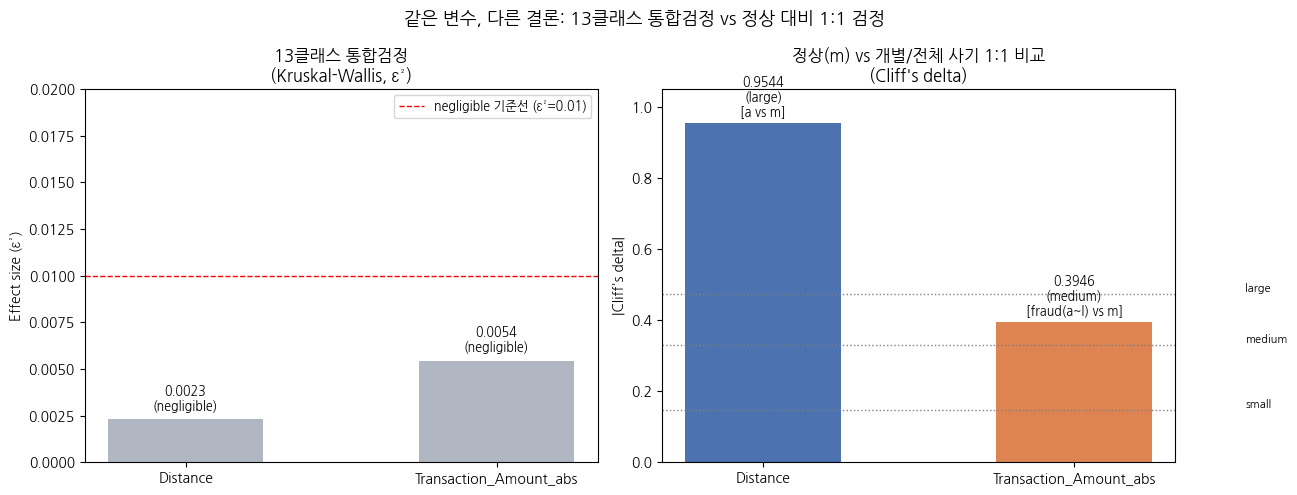

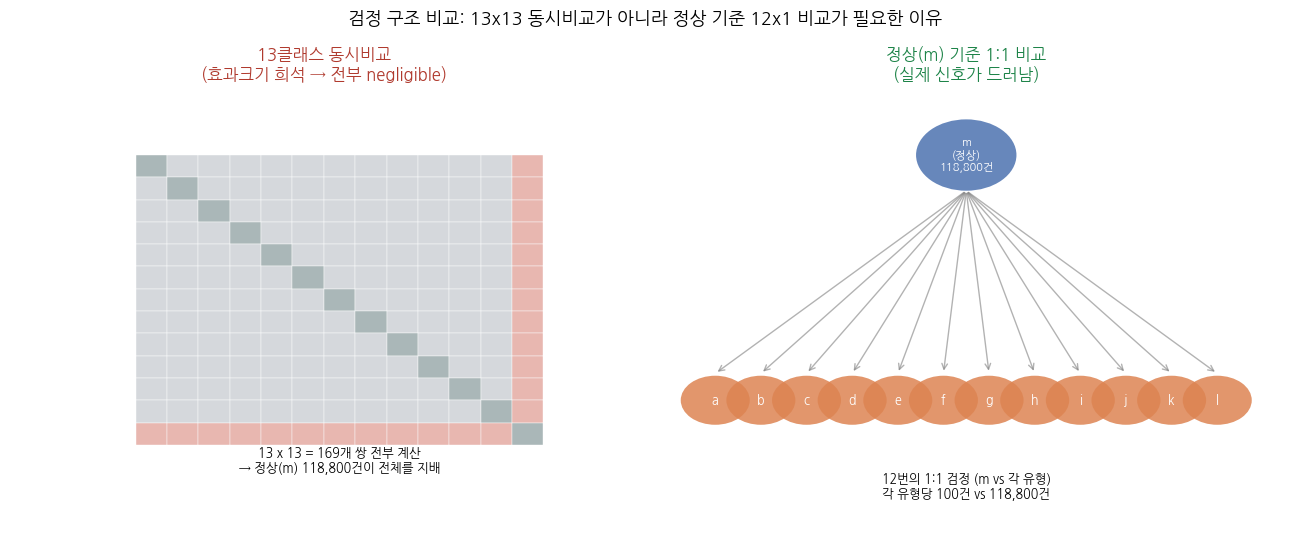

In [ ]:
# ============================================================
# 그룹 1: 방법론 핵심 발견 시각화
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
from scipy import stats

# 한글 폰트
!sudo apt-get -qq install -y fonts-nanum > /dev/null
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

df = train_binary  # 기존 변수 그대로 사용

# --- 파생변수 (없으면 생성) ---
if 'Transaction_Amount_abs' not in df.columns:
    df['Transaction_Amount_abs'] = df['Transaction_Amount'].abs()

# --- 효과크기 계산 함수 ---
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = len(x), len(y)
    u, _ = stats.mannwhitneyu(x, y, alternative='two-sided')
    return (2 * u) / (nx * ny) - 1

def epsilon_squared(groups):
    all_data = np.concatenate(groups)
    n = len(all_data)
    h_stat, p = stats.kruskal(*groups)
    eps2 = h_stat / ((n**2 - 1) / (n + 1))
    return h_stat, p, eps2

def effect_label_cliffs(d):
    d = abs(d)
    if d >= 0.474: return 'large'
    if d >= 0.33:  return 'medium'
    if d >= 0.147: return 'small'
    return 'negligible'

def effect_label_eps2(e):
    if e >= 0.14: return 'large'
    if e >= 0.06: return 'medium'
    if e >= 0.01: return 'small'
    return 'negligible'

# --- 실제 값 계산 ---
groups_distance = [df.loc[df['Fraud_Type']==t, 'Distance'].values for t in sorted(df['Fraud_Type'].unique())]
_, _, eps_distance = epsilon_squared(groups_distance)

groups_amount = [df.loc[df['Fraud_Type']==t, 'Transaction_Amount_abs'].values for t in sorted(df['Fraud_Type'].unique())]
_, _, eps_amount = epsilon_squared(groups_amount)

m_distance = df.loc[df['Fraud_Type']=='m', 'Distance'].values
a_distance = df.loc[df['Fraud_Type']=='a', 'Distance'].values
delta_a_distance = cliffs_delta(a_distance, m_distance)

fraud_amount = df.loc[df['Fraud_Type']!='m', 'Transaction_Amount_abs'].values
m_amount = df.loc[df['Fraud_Type']=='m', 'Transaction_Amount_abs'].values
delta_amount_all = cliffs_delta(fraud_amount, m_amount)

print(f"[13클래스 통합] Distance eps^2={eps_distance:.4f} ({effect_label_eps2(eps_distance)})")
print(f"[13클래스 통합] Amount_abs eps^2={eps_amount:.4f} ({effect_label_eps2(eps_amount)})")
print(f"[1:1] a vs m Distance delta={delta_a_distance:.4f} ({effect_label_cliffs(delta_a_distance)})")
print(f"[1:1] fraud(all) vs m Amount_abs delta={delta_amount_all:.4f} ({effect_label_cliffs(delta_amount_all)})")

# ============================================================
# 그림 1-A: 효과크기 비교 막대그래프
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vars_ = ['Distance', 'Transaction_Amount_abs']
eps2_vals = [eps_distance, eps_amount]
cliffs_vals = [delta_a_distance, delta_amount_all]
labels_1v1 = ['a vs m', 'fraud(a~l) vs m']

ax = axes[0]
bars = ax.bar(vars_, eps2_vals, color='#B0B7C3', width=0.5)
ax.axhline(0.01, color='red', linestyle='--', linewidth=1, label='negligible 기준선 (ε²=0.01)')
ax.set_ylim(0, max(0.02, max(eps2_vals)*1.5))
ax.set_title('13클래스 통합검정\n(Kruskal-Wallis, ε²)', fontsize=12)
ax.set_ylabel('Effect size (ε²)')
for b, v in zip(bars, eps2_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.0005, f'{v:.4f}\n({effect_label_eps2(v)})', ha='center', fontsize=9)
ax.legend(fontsize=9)

ax = axes[1]
colors = ['#4C72B0', '#DD8452']
bars = ax.bar(vars_, [abs(c) for c in cliffs_vals], color=colors, width=0.5)
for yv, lab in [(0.147,'small'), (0.33,'medium'), (0.474,'large')]:
    ax.axhline(yv, color='gray', linestyle=':', linewidth=1)
    ax.text(1.55, yv, lab, fontsize=8, va='bottom')
ax.set_ylim(0, 1.05)
ax.set_title("정상(m) vs 개별/전체 사기 1:1 비교\n(Cliff's delta)", fontsize=12)
ax.set_ylabel("|Cliff's delta|")
for b, v, lab in zip(bars, cliffs_vals, labels_1v1):
    ax.text(b.get_x()+b.get_width()/2, abs(v)+0.02, f'{v:.4f}\n({effect_label_cliffs(v)})\n[{lab}]', ha='center', fontsize=9)

fig.suptitle('같은 변수, 다른 결론: 13클래스 통합검정 vs 정상 대비 1:1 검정', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1a_effect_size_contrast.png', dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# 그림 1-B: 검정 구조 설명 다이어그램 (13x13이 아니라 12(유형)x1(정상))
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('13클래스 동시비교\n(효과크기 희석 → 전부 negligible)', fontsize=12, color='#B03A2E')

grid_labels = list('abcdefghijklm')
n = len(grid_labels)
size = 6.5
x0, y0 = 2, 2
step = size / n
for i, li in enumerate(grid_labels):
    for j, lj in enumerate(grid_labels):
        x = x0 + j*step
        y = y0 + size - (i+1)*step
        color = '#E8B7B0' if 'm' in (li, lj) and li != lj else ('#D5D8DC' if li != lj else '#AAB7B8')
        ax.add_patch(plt.Rectangle((x, y), step, step, facecolor=color, edgecolor='white', linewidth=0.3))
ax.text(x0 + size/2, y0 - 0.6, '13 x 13 = 169개 쌍 전부 계산\n→ 정상(m) 118,800건이 전체를 지배', ha='center', fontsize=9)

ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('정상(m) 기준 1:1 비교\n(실제 신호가 드러남)', fontsize=12, color='#1E8449')

ax.add_patch(plt.Circle((5, 8.5), 0.8, facecolor='#4C72B0', alpha=0.85))
ax.text(5, 8.5, 'm\n(정상)\n118,800건', ha='center', va='center', color='white', fontsize=8, fontweight='bold')

types = list('abcdefghijkl')
xs = np.linspace(1, 9, len(types))
for x, t in zip(xs, types):
    ax.add_patch(plt.Circle((x, 3), 0.55, facecolor='#DD8452', alpha=0.85))
    ax.text(x, 3, t, ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax.annotate('', xy=(x, 3.6), xytext=(5, 7.7),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.6))
ax.text(5, 0.8, '12번의 1:1 검정 (m vs 각 유형)\n각 유형당 100건 vs 118,800건',
        ha='center', fontsize=9)

fig.suptitle('검정 구조 비교: 13x13 동시비교가 아니라 정상 기준 12x1 비교가 필요한 이유', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1b_test_structure_diagram.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac: 'AppleGothic', Linux: 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

FRAUD_ORDER = list('abcdefghijkl') + ['m']
FRAUD_ONLY = list('abcdefghijkl')

flag_cols = [
    'Customer_flag_change_of_authentication_1', 'Customer_flag_change_of_authentication_2',
    'Customer_flag_change_of_authentication_3', 'Customer_flag_change_of_authentication_4',
    'Customer_rooting_jailbreak_indicator', 'Customer_mobile_roaming_indicator',
    'Customer_VPN_Indicator', 'Customer_flag_terminal_malicious_behavior_1',
    'Customer_flag_terminal_malicious_behavior_2', 'Customer_flag_terminal_malicious_behavior_3',
    'Customer_flag_terminal_malicious_behavior_4', 'Customer_flag_terminal_malicious_behavior_5',
    'Customer_flag_terminal_malicious_behavior_6', 'Customer_inquery_atm_limit',
    'Customer_increase_atm_limit', 'Account_indicator_release_limit_excess',
    'Account_indicator_Openbanking', 'Account_release_suspention',
    'Transaction_Failure_Status', 'Another_Person_Account', 'Unused_terminal_status',
    'Flag_deposit_more_than_tenMillion', 'Unused_account_status',
    'Recipient_account_suspend_status', 'First_time_iOS_by_vulnerable_user',
    'Transaction_is_withdrawal',
]

numeric_cols = [
    'Customer_Birthyear', 'Account_initial_balance', 'Account_balance',
    'Account_amount_daily_limit', 'Account_remaining_amount_daily_limit_exceeded',
    'Account_one_month_max_amount', 'Account_one_month_std_dev',
    'Account_dawn_one_month_max_amount', 'Account_dawn_one_month_std_dev',
    'Transaction_num_connection_failure', 'Distance',
    'Number_of_transaction_with_the_account', 'Transaction_history_with_the_account',
    'Time_difference_seconds', 'Transaction_Amount_abs',
]

categorical_cols = [
    'ID', 'Customer_Gender', 'Customer_personal_identifier', 'Customer_identification_number',
    'Customer_credit_rating', 'Customer_loan_type', 'Account_account_number',
    'Account_account_type', 'Channel', 'Operating_System', 'Error_Code',
    'Type_General_Automatic', 'IP_Address', 'MAC_Address', 'Access_Medium',
    'Location_region', 'Recipient_Account_Number',
]

# 범주형 중 식별자성(카디널리티 너무 높음) vs 분석용 자동 분리
id_like_cols = [c for c in categorical_cols if df[c].nunique() > 50]
analysis_cat_cols = [c for c in categorical_cols if c not in id_like_cols]

print('식별자성(분석 제외):', id_like_cols)
print('분석용 범주형:', analysis_cat_cols)

식별자성(분석 제외): ['ID', 'Customer_personal_identifier', 'Customer_identification_number', 'Account_account_number', 'IP_Address', 'MAC_Address', 'Recipient_Account_Number']
분석용 범주형: ['Customer_Gender', 'Customer_credit_rating', 'Customer_loan_type', 'Account_account_type', 'Channel', 'Operating_System', 'Error_Code', 'Type_General_Automatic', 'Access_Medium', 'Location_region']


### 12-2. 폰트 재설치 및 스타일 세팅

In [ ]:
# 1) 폰트 설치
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

# 2) style 세팅을 먼저
sns.set_style('whitegrid')

# 3) 폰트 설정은 반드시 그 이후에, 마지막에
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
# 4) 괴리 큰 변수부터 boxplot(전체) + violin(사기끼리) 페어로 시각화
top_cols = deviation_score.head(8).index.tolist()
n = len(top_cols)

fig, axes = plt.subplots(n, 2, figsize=(16, 4 * n))

for i, col in enumerate(top_cols):
    ax_box, ax_violin = axes[i, 0], axes[i, 1]

    sns.boxplot(data=df, x='Fraud_Type', y=col, order=FRAUD_ORDER, ax=ax_box)
    ax_box.set_yscale('symlog')
    ax_box.set_title(f'{col} - 전체 (m 포함, symlog)')

    sub = df[df['Fraud_Type'] != 'm']
    sns.violinplot(data=sub, x='Fraud_Type', y=col, order=FRAUD_ONLY, ax=ax_violin, cut=0, inner='quartile')
    ax_violin.set_title(f'{col} - 사기유형(a~l)만')

plt.tight_layout()
plt.show()

NameError: name 'deviation_score' is not defined

### 12-3. 전체 개요 z-score 히트맵 (15개 변수 x 12유형)

In [ ]:
# 3) 전체 개요용 히트맵 - 15개 변수 x 12유형 괴리도(z-score) 한 장에 몰아보기
plt.figure(figsize=(12, 8))
sns.heatmap(deviation.T, annot=True, fmt='.1f', cmap='coolwarm', center=0,
            cbar_kws={'label': '정상 대비 괴리(z-score)'})
plt.title('Fraud_Type별 수치형 변수 - 정상(m) 대비 괴리도')
plt.tight_layout()
plt.show()

### 12-4. 세부 시각화 A

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FRAUD_ORDER = list('abcdefghijkl') + ['m']
FRAUD_ONLY = list('abcdefghijkl')

flag_cols = [
    'Customer_flag_change_of_authentication_1', 'Customer_flag_change_of_authentication_2',
    'Customer_flag_change_of_authentication_3', 'Customer_flag_change_of_authentication_4',
    'Customer_rooting_jailbreak_indicator', 'Customer_mobile_roaming_indicator',
    'Customer_VPN_Indicator', 'Customer_flag_terminal_malicious_behavior_1',
    'Customer_flag_terminal_malicious_behavior_2', 'Customer_flag_terminal_malicious_behavior_3',
    'Customer_flag_terminal_malicious_behavior_4', 'Customer_flag_terminal_malicious_behavior_5',
    'Customer_flag_terminal_malicious_behavior_6', 'Customer_inquery_atm_limit',
    'Customer_increase_atm_limit', 'Account_indicator_release_limit_excess',
    'Account_indicator_Openbanking', 'Account_release_suspention',
    'Transaction_Failure_Status', 'Unused_terminal_status',
    'Flag_deposit_more_than_tenMillion', 'Unused_account_status',
    'Recipient_account_suspend_status', 'First_time_iOS_by_vulnerable_user',
]
flag_cols = [c for c in flag_cols if df[c].nunique() > 1]

flag_rate = df.groupby('Fraud_Type')[flag_cols].mean().loc[FRAUD_ORDER]
overall = flag_rate.loc['m'].replace(0, np.nan)
flag_lift = flag_rate.div(overall, axis=1)

# 발생률 기준으로 변수 정렬(=시각적으로 패턴 잘 보이게) - 사기유형 평균 발생률 높은 순
sort_order = flag_rate.loc[FRAUD_ONLY].mean().sort_values(ascending=False).index
flag_rate_sorted = flag_rate[sort_order]
flag_lift_sorted = flag_lift[sort_order]

fig, axes = plt.subplots(2, 1, figsize=(16, 18))

# ① 발생률 히트맵 (m 포함 전체)
sns.heatmap(flag_rate_sorted.T, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, cbar_kws={'label': '발생률'}, ax=axes[0])
axes[0].set_title('Fraud_Type별 플래그 발생률 (전체, m 포함)', fontsize=13)
axes[0].set_xlabel('Fraud_Type')

# ② 정상 대비 Lift 히트맵 (m 대비 몇 배인지 - 시그니처 발굴용)
sns.heatmap(flag_lift_sorted.T, annot=True, fmt='.1f', cmap='coolwarm', center=1,
            linewidths=0.5, cbar_kws={'label': '정상(m) 대비 배율'}, ax=axes[1])
axes[1].set_title('Fraud_Type별 플래그 Lift (정상=1 기준)', fontsize=13)
axes[1].set_xlabel('Fraud_Type')

plt.tight_layout()
plt.show()

### 12-5. 세부 시각화 B

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FRAUD_ORDER = list('abcdefghijkl') + ['m']
FRAUD_ONLY = list('abcdefghijkl')

cat_cols = ['Customer_Gender','Customer_credit_rating', 'Customer_loan_type', 'Account_account_type',
            'Channel', 'Operating_System', 'Error_Code', 'Type_General_Automatic',
            'Access_Medium', 'Location_region']

def get_lift(col):
    ct = pd.crosstab(df['Fraud_Type'], df[col], normalize='index').loc[FRAUD_ORDER]
    overall = ct.loc['m'].replace(0, np.nan)
    return ct.div(overall, axis=1)

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(14, 3.2 * len(cat_cols)))

for ax, col in zip(axes, cat_cols):
    lift = get_lift(col).loc[FRAUD_ONLY]
    sns.heatmap(lift.T, annot=True, fmt='.1f', cmap='coolwarm', center=1,
                linewidths=0.5, cbar_kws={'label': 'Lift'}, ax=ax)
    ax.set_title(f'Fraud_Type별 {col} Lift (정상=1 기준)', fontsize=12)
    ax.set_xlabel('')

axes[-1].set_xlabel('Fraud_Type')
plt.tight_layout()
plt.show()

### 12-6. ID성 컬럼 점검 (유형 간 중복 여부)

In [ ]:
id_like_cols = ['ID','Customer_personal_identifier',
                'Customer_identification_number', 'Account_account_number',
                'IP_Address', 'MAC_Address', 'Recipient_Account_Number']

In [ ]:
print(f"{'컬럼':40s} {'고유값 수':>10s} {'여러유형에 걸친 값':>18s}")
for col in id_like_cols:
    n_unique = df[col].nunique()
    dup = df.groupby(col)['Fraud_Type'].nunique()
    multi_type = (dup > 1).sum()
    print(f"{col:40s} {n_unique:>10d} {multi_type:>18d}")

# 13. 파생변수 생성

> ⚠️ **재정리 중 발견한 이슈**: 원본 코드에서 `weak_signal_composite_score` 계산 시 사용하는 `_composite_cols`가 어디서도 정의되어 있지 않아 `NameError`가 발생합니다. 아래에 d유형 약신호 후보 컬럼으로 `_composite_cols`를 정의하는 코드를 추가했습니다. 실제 의도한 컬럼 목록과 다르면 수정해주세요.

In [ ]:
# _composite_cols 정의 (원본에 누락되어 있던 부분 -- d유형 약신호 후보 컬럼들)_composite_cols = [    'Account_balance',    'Unused_terminal_status',    'unused_terminal_and_internet',    'limit_check_then_transfer',    'Account_amount_daily_limit',]

> 🐛 **위 셀은 실행해도 아무 일도 하지 않는다.**
>
> 주석과 대입문이 **한 줄에 붙어 있어** `_composite_cols = [...]` 전체가 주석 안에 들어가 있다.
> 즉 원본 노트북이 이미 한 번 고치려 했던 `NameError` 가 **고쳐지지 않은 채 남아 있다.**
> (해당 셀에 실행 출력이 하나도 없는 것이 그 흔적이다.)
>
> 아래 셀이 실제로 동작하는 정의다. 원본 셀은 대조를 위해 그대로 두었다.
> 컬럼 목록은 원본 주석의 의도(`d` 유형 약신호 후보)를 그대로 옮긴 것이며,
> **팀이 의도한 목록과 다를 수 있다** — 확인 후 갱신 필요.
>
> 상세: [`docs/03a_issues_data_modeling.md` #A-9](../../docs/03a_issues_data_modeling.md)


In [ ]:
# 🐛 FIX(포트폴리오 정리) — 위 셀은 전체가 주석이라 _composite_cols 가 정의되지 않는다.
#   d 유형 약신호 후보 컬럼 (원본 주석의 의도를 그대로 옮김)
_composite_cols = [
    'Account_balance',
    'Unused_terminal_status',
    'unused_terminal_and_internet',
    'limit_check_then_transfer',
    'Account_amount_daily_limit',
]
print(f'_composite_cols 정의됨: {len(_composite_cols)}개 — {_composite_cols}')


In [ ]:
import pandas as pd
import numpy as np

# ── 1. Amount_vs_monthly_max_ratio ──
# 이번 거래금액이 계좌의 평소 월간 최대거래금액 대비 얼마나 큰지
df['Amount_vs_monthly_max_ratio'] = (
    df['Transaction_Amount_abs'] / df['Account_one_month_max_amount'].replace(0, np.nan)
)

# ── 2. Amount_vs_remaining_balance ──
# 이번 거래금액이 거래 후 남은 잔액 대비 얼마나 큰지 (+1은 0으로 나누는 것 방지)
df['Amount_vs_remaining_balance'] = (
    df['Transaction_Amount_abs'] / (df['Account_balance'].clip(lower=0) + 1)
)

# ── 3. Amount_vs_daily_limit ──
# 이번 거래금액이 계좌 일일한도 대비 얼마나 큰지 (i 유형 최강 시그니처)
df['Amount_vs_daily_limit'] = (
    df['Transaction_Amount_abs'] / df['Account_amount_daily_limit'].replace(0, np.nan)
)

# ── 4. Transaction_Hour / Is_dawn ──
# 거래 발생 시각 및 새벽(0~5시) 여부
df['Transaction_Hour'] = df['Transaction_Datetime'].dt.hour
df['Is_dawn'] = ((df['Transaction_Hour'] >= 0) & (df['Transaction_Hour'] < 6)).astype(int)


# ── 5. unused_terminal_and_internet (d 유형) ──
df['unused_terminal_and_internet'] = (
    (df['Unused_terminal_status'] == 1) & (df['Channel'] == 'internet')
).astype(int)

# ── 6. limit_check_then_transfer (d 유형) ──
df['limit_check_then_transfer'] = (
    (df['Customer_inquery_atm_limit'] == 1)
    & (df['Customer_increase_atm_limit'] == 1)
    & (df['Channel'] == 'internet')
).astype(int)


_normal = df[df['Fraud_Type'] == 'm']  # 정상 기준 평균/표준편차로 z-score 계산

weak_signal_score = pd.Series(0.0, index=df.index)
for col in _composite_cols:
    mean_m, std_m = _normal[col].mean(), _normal[col].std()
    z = (df[col] - mean_m) / std_m
    weak_signal_score += z.abs()
df['weak_signal_composite_score'] = weak_signal_score

# ── 9. large_deposit_and_remote_control (e 유형) ──
df['large_deposit_and_remote_control'] = (
    (df['Flag_deposit_more_than_tenMillion'] == 1)
    & (df['Customer_flag_terminal_malicious_behavior_2'] == 1)
).astype(int)

# 14. 2차 EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'NanumGothic'  # 한글 폰트는 이미 설치되어 있다고 가정
plt.rcParams['axes.unicode_minus'] = False

FRAUD_ORDER = list('abcdefghijkl') + ['m']
FRAUD_ONLY = list('abcdefghijkl')

# ============================================================
# 1. 연속형 비율 파생변수 3종 - boxplot(전체) + violin(사기유형만)
# ============================================================
ratio_cols = ['Amount_vs_monthly_max_ratio', 'Amount_vs_remaining_balance', 'Amount_vs_daily_limit']

fig, axes = plt.subplots(len(ratio_cols), 2, figsize=(16, 4.5 * len(ratio_cols)))

for i, col in enumerate(ratio_cols):
    ax_box, ax_violin = axes[i, 0], axes[i, 1]

    sns.boxplot(data=df, x='Fraud_Type', y=col, order=FRAUD_ORDER, ax=ax_box)
    ax_box.set_yscale('log')
    ax_box.set_title(f'{col} - 전체(m 포함, log)')

    sub = df[df['Fraud_Type'] != 'm']
    sns.violinplot(data=sub, x='Fraud_Type', y=col, order=FRAUD_ONLY, ax=ax_violin, cut=0, inner='quartile')
    ax_violin.set_yscale('log')
    ax_violin.set_title(f'{col} - 사기유형(a~l)만')

plt.tight_layout()
plt.show()

# ============================================================
# 2. Is_dawn (새벽거래 비율) - 막대그래프, i 강조
# ============================================================
dawn_rate = df.groupby('Fraud_Type')['Is_dawn'].mean().loc[FRAUD_ORDER]

plt.figure(figsize=(12, 5))
colors = ['#d62728' if t == 'i' else '#4c72b0' for t in FRAUD_ORDER]
bars = plt.bar(FRAUD_ORDER, dawn_rate.values, color=colors)
plt.axhline(dawn_rate['m'], color='gray', linestyle='--', label=f"정상(m) 기준선 = {dawn_rate['m']:.2f}")
plt.title('Fraud_Type별 새벽(0~5시) 거래 비율')
plt.ylabel('새벽 거래 비율')
plt.legend()
for bar, val in zip(bars, dawn_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


# ============================================================
# 3. d 유형 전용: 조합 플래그 2개 + weak_signal_composite_score
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes[:2], ['unused_terminal_and_internet', 'limit_check_then_transfer']):
    rate = df.groupby('Fraud_Type')[col].mean().loc[FRAUD_ORDER]
    colors = ['#d62728' if t == 'd' else '#4c72b0' for t in FRAUD_ORDER]
    ax.bar(FRAUD_ORDER, rate.values, color=colors)
    ax.axhline(rate['m'], color='gray', linestyle='--')
    ax.set_title(col)
    ax.set_ylabel('발생률')

sns.boxplot(data=df, x='Fraud_Type', y='weak_signal_composite_score', order=FRAUD_ORDER, ax=axes[2])
axes[2].set_title('weak_signal_composite_score (d 종합 이상신호 점수)')

plt.tight_layout()
plt.show()

# ============================================================
# 4. e 유형 전용: large_deposit_and_remote_control (e vs f/g 분리 확인)
# ============================================================
rate = df.groupby('Fraud_Type')['large_deposit_and_remote_control'].mean().loc[FRAUD_ORDER]
plt.figure(figsize=(12, 5))
colors = ['#d62728' if t == 'e' else ('#ffa600' if t in ['f', 'g'] else '#4c72b0') for t in FRAUD_ORDER]
bars = plt.bar(FRAUD_ORDER, rate.values, color=colors)
plt.axhline(rate['m'], color='gray', linestyle='--', label=f"정상(m) 기준선 = {rate['m']:.2f}")
plt.title('large_deposit_and_remote_control 발생률 (빨강=e, 주황=f/g)')
plt.legend()
for bar, val in zip(bars, rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================
# 5. 미확정 유형(d, i) 확대 비교 - 핵심 파생변수만 정상과 대조
# ============================================================
zoom_cols = ['Amount_vs_remaining_balance', 'Amount_vs_daily_limit', 'weak_signal_composite_score']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
target_types = ['d', 'i', 'm']

for ax, col in zip(axes, zoom_cols):
    sub = df[df['Fraud_Type'].isin(target_types)]
    sns.boxplot(data=sub, x='Fraud_Type', y=col, order=target_types, ax=ax)
    if df[col].max() / (df[col].min() + 1e-9) > 100:
        ax.set_yscale('log')
    ax.set_title(col)

plt.suptitle('d, i vs 정상 - 핵심 파생변수 확대 비교', y=1.02)
plt.tight_layout()
plt.show()

# 15. 인코딩 및 학습/검증 전처리 파일 추출

### 15-1. 범주형 변수 인코딩`df`(전체 train + 파생변수)의 범주형(object) 컬럼을 LabelEncoder로 인코딩한다. 인코더는 `label_encoders.pkl`로 저장해 test.csv 적용 시 재사용한다.

In [ ]:
from sklearn.preprocessing import LabelEncoderimport pickletarget_col = 'Fraud_Type'# 인코딩 대상: object 타입 전체 (타깃 제외)categorical_cols = [c for c in df.select_dtypes(include='object').columns if c != target_col]print('인코딩 대상 범주형 컬럼 수:', len(categorical_cols))print(categorical_cols)label_encoders = {}for col in categorical_cols:    le = LabelEncoder()    df[col] = le.fit_transform(df[col].astype(str))    label_encoders[col] = lewith open('label_encoders.pkl', 'wb') as f:    pickle.dump(label_encoders, f)print('label_encoders.pkl 저장 완료')

### 15-2. 타깃 인코딩`Fraud_Type`(a~l, m)을 알파벳 순으로 0~12에 매핑한다 (m=12=정상). 인코더는 `le_target.pkl`로 저장한다.

In [ ]:
le_target = LabelEncoder()df['y'] = le_target.fit_transform(df[target_col])print('클래스 매핑:')for cls, code_ in zip(le_target.classes_, le_target.transform(le_target.classes_)):    print(f'  {cls} -> {code_}')with open('le_target.pkl', 'wb') as f:    pickle.dump(le_target, f)print('le_target.pkl 저장 완료')

### 15-3. 학습 제외 컬럼 정의 (식별자 / 원본 datetime / 타깃)모델 입력으로 부적절한 식별자·원본 datetime·타깃 컬럼을 제외하고 최종 피처 목록을 확정한다.

In [ ]:
drop_cols_final = [    'ID', 'Customer_personal_identifier', 'Customer_identification_number',    'Customer_registration_datetime', 'Account_account_number', 'Account_creation_datetime',    'Transaction_Datetime', 'IP_Address', 'MAC_Address', 'Location', 'Recipient_Account_Number',    'Last_atm_transaction_datetime', 'Last_bank_branch_transaction_datetime',    'Transaction_resumed_date', target_col, 'y']# 존재하는 컬럼만 필터링 (버전에 따라 일부 없을 수 있음)drop_cols_final = [c for c in drop_cols_final if c in df.columns]feature_cols = [c for c in df.columns if c not in drop_cols_final]print('최종 피처 수:', len(feature_cols))print(feature_cols)

### 15-4. 9절에서 확정한 분할(tr_idx/va_idx)로 X/y 분리9절 `StratifiedGroupKFold`로 만든 `tr_idx`, `va_idx`(고객·계좌 그룹 누수 0건, 13클래스 양쪽 존재 검증 완료)를 그대로 재사용해 `df`(파생변수까지 포함된 전체 데이터)를 학습/검증으로 분리한다.> ⚠️ 주의: `tr_idx`/`va_idx`는 9절 시점의 `train` 행 순서 기준 위치(iloc) 인덱스다. 9절 이후 어떤 셀에서도 `df`(=train 복사본)의 행을 추가/삭제/재정렬하지 않았는지 반드시 확인한 뒤 사용할 것.

In [ ]:
X = df[feature_cols]y_all = df['y']X_tr = X.iloc[tr_idx].reset_index(drop=True)X_va = X.iloc[va_idx].reset_index(drop=True)y_tr = y_all.iloc[tr_idx].reset_index(drop=True)y_va = y_all.iloc[va_idx].reset_index(drop=True)print('X_tr:', X_tr.shape)print('X_va:', X_va.shape)print('y_tr 분포:')print(y_tr.value_counts().sort_index())print('y_va 분포:')print(y_va.value_counts().sort_index())

### 15-5. 결측치 최종 점검비율형 파생변수(0으로 나누기 방지용 결측 등)에 남아있는 결측을 확인한다. LightGBM은 결측을 자체 처리하므로 별도 대치 없이 그대로 둔다.

In [ ]:
na_counts = X_tr.isna().sum()print('결측 존재 컬럼:')print(na_counts[na_counts > 0])

### 15-6. 전처리 완료 파일 저장 (parquet)이후 모델링 단계에서 바로 불러와 쓸 수 있도록 `X_tr`, `X_va`, `y_tr`, `y_va`를 parquet으로 저장한다.

In [ ]:
X_tr.to_parquet('X_tr.parquet')X_va.to_parquet('X_va.parquet')y_tr.to_frame(name='y').to_parquet('y_tr.parquet')y_va.to_frame(name='y').to_parquet('y_va.parquet')print('저장 완료: X_tr.parquet, X_va.parquet, y_tr.parquet, y_va.parquet')